# 데이터 수집.분석 프로세스/플로우

1. 데이터 수집
- crawling with python (requests, bs4, selenium, scrapy)
- open API (공공데이터포털, NAVER, Kakao 등)
- Research (구글 Form, Desk : Opensurvey 외 NAS, MEJO)

2. 데이터 저장
- RDBMS (MySQL > SQL)
- NoSQL (MongoDB > NoSQL)

3. 데이터 구조
- PlainText, json, xml, csv

4. 탐색적 데이터 분석
- EDA

5. 데이터 전처리(정제)
- pandas in python (1차원 series, 2차원 dataframe)

6. 데이터 시각화
- plotly in python

In [1]:
# matplotlib, seaborn => 과거에 많이 사용했던 라이브러리 모듈
# matplotlib : 웹 기반의 시각화 x, 도면설계, 측량, 계측 등을 목적 탄생 (인치 단위, 문법 어려움, 컬러색상 등 옵션 선택 x)
# seaborn : 컬러기반 시각화 메리트, 주체적으로 도표 및 차트 제작 x

# plotly = matplotlib + seaborn

# 1) plotly express : 빠르고 간단하게 시각화
# 간단한 코드를 입력해서 빠르게 EDA
# 그래프 혹은 차트 정밀한 수정.편집 x

# 2) plotly graph objects : 세밀하고 다양한 시각화
# 시각화 그래프 차트의 종류가 다양함
# 상대적으로 express 대비, 코드가 길고 복잡함

In [2]:
# 라이브러리 설치 (현 시점, 내장)

!pip install plotly

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


1. plotly express 기본코드패턴

import plotly.express as px

fig = px.그래프종류(
    데이터프레임, -> pandas를 통해서 생성된
    x='x축열 이름',
    y='y축열 이름',
    title='그래프|차트 제목'
)

fig.show() -> 위에서 설정한 그래프값을 실제 출력시켜주는 명령 메서드

2. plotly express 활용, 자주 빈번하게 사용하는 그래프|차트 종류(목록)

1) 산점도 (scatter)
> 각 데이터간 상관관계 분석, 전체 데이터의 밀집도
> 매출대비, 이익 상관관계 // 저가, 고가 등 파악

px.scatter(df, x='x열', y='y열', color='색상범례값설정')

2) 선그래프 (line)
> 시계열차트, 시간경과에 따라서 데이터의 증감 추이를 파악 (주식차트)
> 기존 과거 데이터를 기반 -> 증가, 감소 (마케팅 예측, 대안 전략수립)
> 웹사이트 유입 트래픽 -> 어떤 시간대 유입, 요일 구매 많이

px.line(df, x='x열', y='y열')

3) 막대그래프 (bar)
> 서로 다른 데이터들 간 개별적인 수치값을 비교하려고 하는 경우
> 절대빈도 차트 / A, B -> 시험성적 비교 /
> 브랜드별 분기 매출 지표

px.bar(df, x='범주열', y='값')

4) 히스토그램 (histogram)
> 과거로부터 이어저온 데이터의 누적된 흐름을 보려고 할 때
> 특정 시점의 앞.뒤 데이터가 붙어져있어서 전체적인 흐름 판단이 용이
> 해당 기간 동안의 데이터의 그룹화 (군집화) 가능
> 2년의 기간 > 8개의 그룹으로 나눠서

px.histogram(df, x='데이터열', nbins = 몇 개의 구간으로 나눠서 데이터를 볼 것인가)

5) 상자그림 (boxplot)
> 특정 데이터그룹의 최소.최대.중앙.평균.이상치 값을 한번에 박스형태로 보여줌
> 상자(해당 데이터 그룹의 보편화된 값이 어디에 몰려있는가)
> 이상치(특이값 도출, 왜, 증가, 감소)

px.box(df, y=['비교하고자 하는 각 열'])

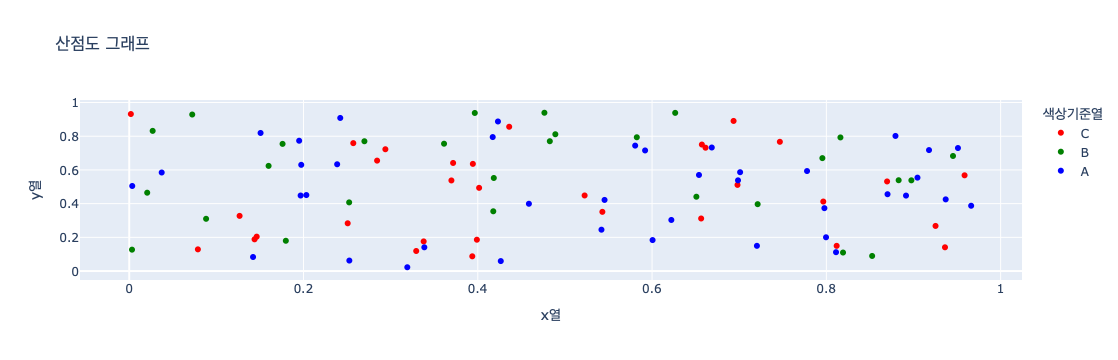

In [24]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0부터 1미만의 실수자료형을 난수형태로 100개 생성 (중복 허용)
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) # 최대한 비중을 근사치로 만들어줍니다. 34, 33, 33
})

fig = px.scatter(df, x="x열", y="y열", color="색상기준열", color_discrete_sequence=["red", "green", "blue"], title="산점도 그래프")

fig.show()

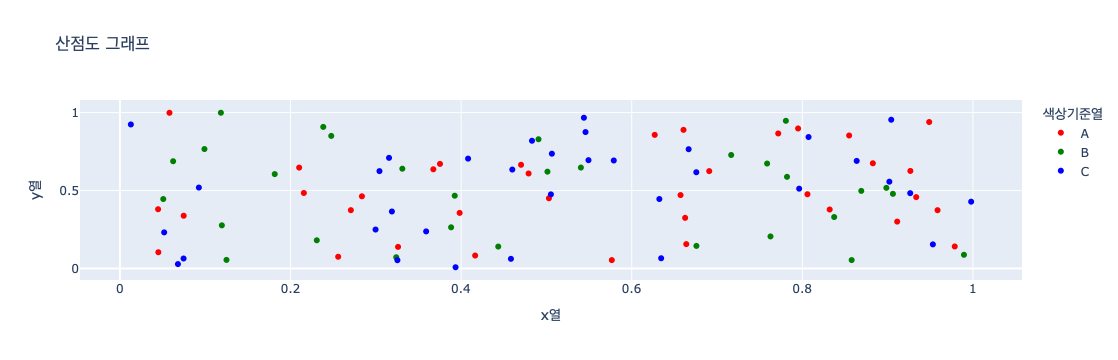

In [26]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0부터 1미만의 실수자료형을 난수형태로 100개 생성 (중복 허용)
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) # 최대한 비중을 근사치로 만들어줍니다. 34, 33, 33
})

df["색상기준열"] = pd.Categorical(df["색상기준열"], categories=["A", "B", "C"], ordered=True) # 재확인!!

fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"], title="산점도 그래프")

fig.show()

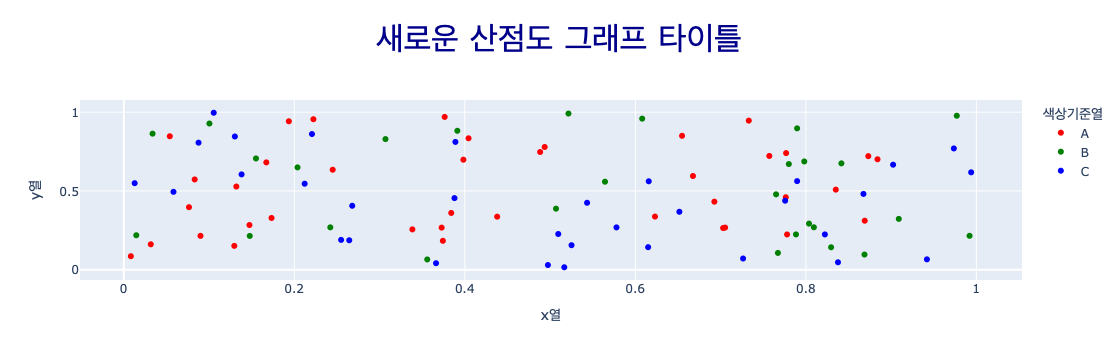

In [37]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0부터 1미만의 실수자료형을 난수형태로 100개 생성 (중복 허용)
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) # 최대한 비중을 근사치로 만들어줍니다. 34, 33, 33
})

df["색상기준열"] = pd.Categorical(df["색상기준열"], categories=["A", "B", "C"], ordered=True) # 재확인!!

fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"], title="산점도 그래프")

fig.update_layout(
    title={
        "text": "새로운 산점도 그래프 타이틀",
        "font": {
            "size": 32,
            "color": "darkblue"
        },
        "x": 0.5
    }
)

fig.show()

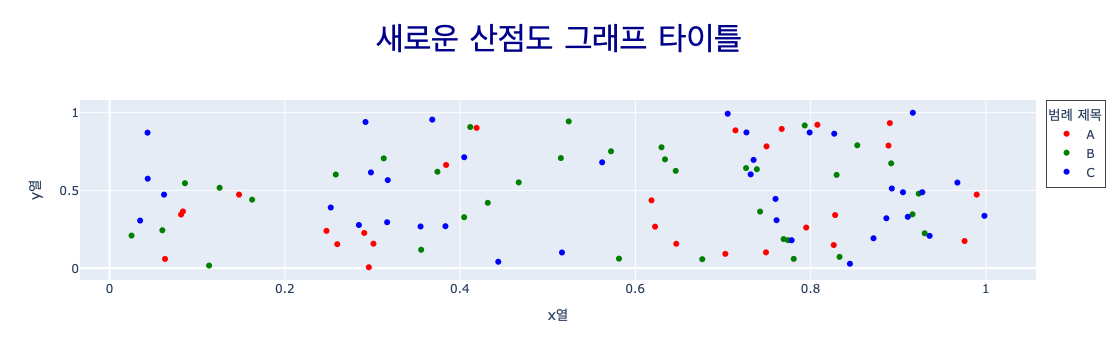

In [57]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0부터 1미만의 실수자료형을 난수형태로 100개 생성 (중복 허용)
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) # 최대한 비중을 근사치로 만들어줍니다. 34, 33, 33
})

df["색상기준열"] = pd.Categorical(df["색상기준열"], categories=["A", "B", "C"], ordered=True) # 재확인!!

fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"], title="산점도 그래프")

fig.update_layout(
    title={
        "text": "새로운 산점도 그래프 타이틀",
        "font": {
            "size": 32,
            "color": "darkblue"
        },
        "x": 0.5
    },
    legend={
        "title": "범례 제목",
        "x": 1.01,
        "y": 1,
        "xanchor": "left",
        "yanchor": "top",
        "borderwidth": 1
    }
)

fig.show()

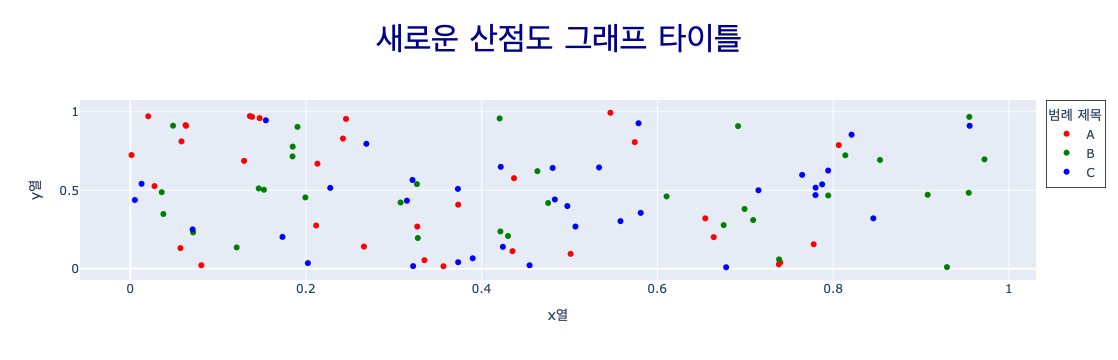

In [60]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0부터 1미만의 실수자료형을 난수형태로 100개 생성 (중복 허용)
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) # 최대한 비중을 근사치로 만들어줍니다. 34, 33, 33
})

df["색상기준열"] = pd.Categorical(df["색상기준열"], categories=["A", "B", "C"], ordered=True) # 재확인!!

fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"], title="산점도 그래프")

fig.update_layout(
    title={
        "text": "새로운 산점도 그래프 타이틀",
        "font": {
            "size": 32,
            "color": "darkblue"
        },
        "x": 0.5
    },
    legend=dict(
        title="범례 제목",
        x=1.01,
        y=1,
        xanchor="left",
        yanchor="top",
        borderwidth=1
    )
)

fig.show()

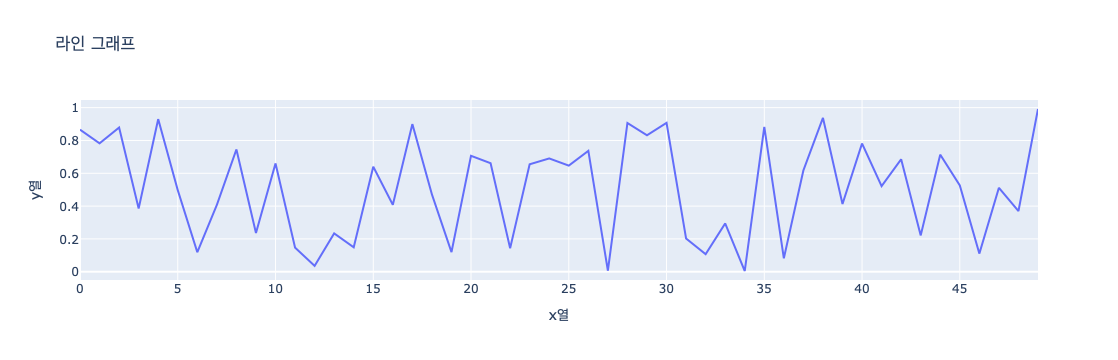

In [61]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.arange(50), # 0부터 시작해서 49까지, 토탈 50개의 정수를 1차원의 배열 = 리스트로 생성 [0, 1, 2, 3, 4, 5, 6, ... 49]
    "y열": np.random.rand(50) # 0부터 1미만 실수자료형 값을 난수형태로 50개 생성
})

fig = px.line(df, x="x열", y="y열", title="라인 그래프")
fig.show()

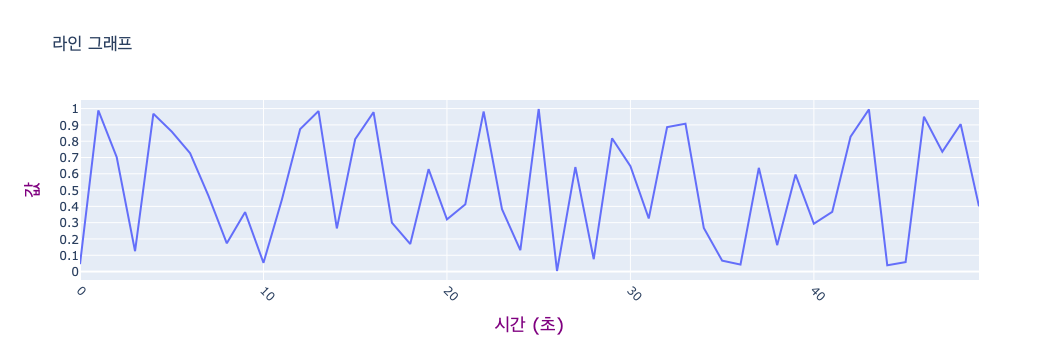

In [74]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.arange(50), # 0부터 시작해서 49까지, 토탈 50개의 정수를 1차원의 배열 = 리스트로 생성 [0, 1, 2, 3, 4, 5, 6, ... 49]
    "y열": np.random.rand(50) # 0부터 1미만 실수자료형 값을 난수형태로 50개 생성
})

fig = px.line(df, x="x열", y="y열", title="라인 그래프")

fig.update_xaxes(
    title_text="시간 (초)",
    title_font=dict(size=18, color="purple"),
    tickangle=45,
    dtick=10
)

fig.update_yaxes(
    title_text="값",
    title_font=dict(size=18, color="purple"),
    tickfont=dict(size=12),
    dtick=0.1
)

fig.show()

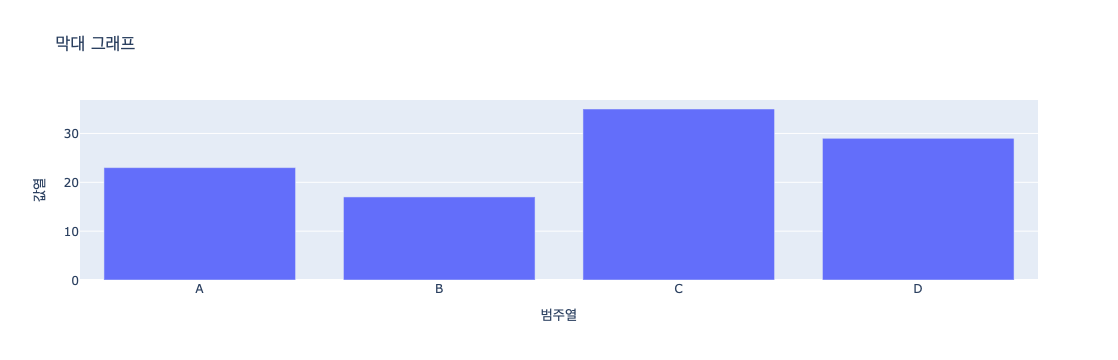

In [20]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "범주열": ["A", "B", "C", "D"],
    "값열": [23, 17, 35, 29]
})

fig = px.bar(df, x="범주열", y="값열", title="막대 그래프")
fig.show()

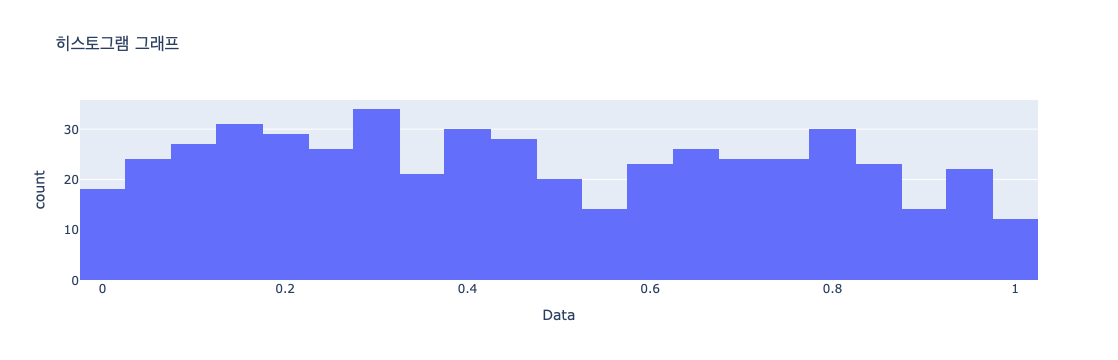

In [21]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Data": np.random.rand(500)
})

fig = px.histogram(df, x="Data", nbins=30, title="히스토그램 그래프")
fig.show()

In [27]:
np.random.rand(100) # 0과 1사이의 실수자료형 값을 가지고 있는 1차원 배열 = 리스트
# 2차원 배열 (행, 열)

array([0.52939228, 0.6918527 , 0.52428261, 0.97037959, 0.99128219,
       0.24140481, 0.51465653, 0.5872385 , 0.56310706, 0.95076629,
       0.31471343, 0.53160572, 0.79955591, 0.61242039, 0.19126386,
       0.28125865, 0.73814291, 0.09624653, 0.50860007, 0.3520548 ,
       0.99720324, 0.73964751, 0.62314756, 0.97503872, 0.49855424,
       0.90458857, 0.00413156, 0.65507034, 0.31876693, 0.12392188,
       0.68790945, 0.15928779, 0.85985022, 0.45735227, 0.88309116,
       0.59427041, 0.60274797, 0.76953004, 0.85544873, 0.92165389,
       0.16842374, 0.9573149 , 0.96269618, 0.12423164, 0.825076  ,
       0.67372721, 0.55927145, 0.68419775, 0.18020285, 0.00808248,
       0.35773271, 0.97291566, 0.75365036, 0.84000967, 0.96243932,
       0.60611023, 0.20072422, 0.58879493, 0.18719393, 0.13320896,
       0.1863242 , 0.37718029, 0.05436812, 0.1960145 , 0.66465189,
       0.49091192, 0.93291286, 0.83194815, 0.69825975, 0.29816706,
       0.28483873, 0.69921158, 0.2151548 , 0.57685956, 0.29766

In [28]:
np.random.rand(100, 2)

array([[0.61088991, 0.87048538],
       [0.83923831, 0.49982606],
       [0.00348785, 0.09808877],
       [0.17989799, 0.3136395 ],
       [0.43947744, 0.15667868],
       [0.90657593, 0.25548693],
       [0.7179149 , 0.1997225 ],
       [0.26826977, 0.65203309],
       [0.68011969, 0.25767354],
       [0.53970299, 0.86366932],
       [0.61165765, 0.72353287],
       [0.8548306 , 0.25800569],
       [0.70262198, 0.36705225],
       [0.05348598, 0.67314941],
       [0.87593125, 0.18428231],
       [0.10944231, 0.99885602],
       [0.18861221, 0.72943151],
       [0.27933323, 0.50033097],
       [0.19935739, 0.96236945],
       [0.92089482, 0.69022266],
       [0.72419389, 0.51458411],
       [0.32083285, 0.53428347],
       [0.22993316, 0.04787444],
       [0.24853542, 0.77161248],
       [0.53217769, 0.34309287],
       [0.22549458, 0.75984658],
       [0.10631434, 0.16294659],
       [0.89348774, 0.88088673],
       [0.1143099 , 0.11806334],
       [0.09821832, 0.29103113],
       [0.

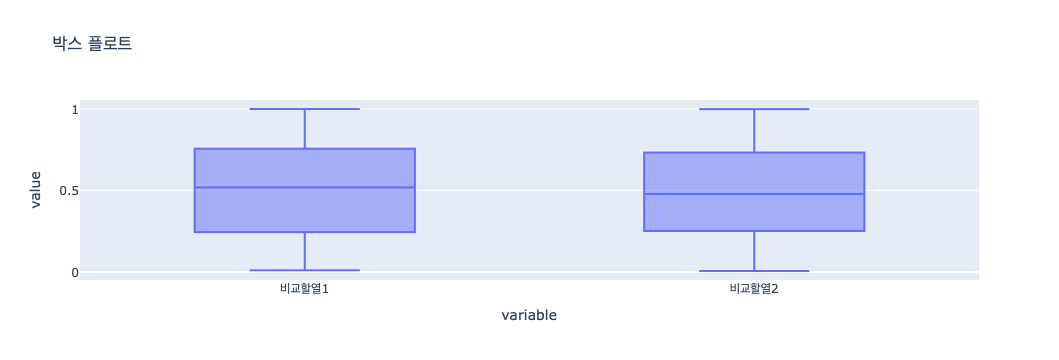

In [29]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.rand(100, 2), columns=["비교할열1", "비교할열2"])

fig = px.box(df, y=["비교할열1", "비교할열2"], title="박스 플로트")

fig.show()

# df = pd.DataFrame({
#     "Dave": [1, 2, 3],
#     "David": [4, 5, 6]
# }, columns=["F1", "F2"])

In [30]:
df

,비교할열1,비교할열2
0,0.481668,0.668604
1,0.149844,0.568549
2,0.435048,0.468539
3,0.533106,0.819763
4,0.608907,0.703293
...,...,...
95,0.957175,0.310674
96,0.503047,0.087217
97,0.426911,0.979667
98,0.301189,0.070046


In [75]:
# plotly express 추가옵션

# 1) fig.update_layout() : 전체 레이아웃(제목, 범례, 여백 등)을 수정.편집 -> title, legend
# 2) fig.update_xaxes() : x축의 속성(제목, 글꼴, 눈금 등)을 수정.편집 -> title_text, title_font, tickangle, dtick
# 3) fig.update_yaxes() : y축의 속성(제목, 글꼴, 눈금 등)을 수정.편집 -> title_text, title_font, tickangle, dtick